In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import cartopy.crs as ccrs
import cartopy.feature as cf
import datetime

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 397292


In [2]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)

In [3]:
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
BC_d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
noBC_d4pdf = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_HPB_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

d4pdf_vege = vege_ds_coarsened.interp(longitude=BC_d4pdf.longitude, latitude=BC_d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

box = [(32,55),(232,256)]

ERA5 = ERA5.where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
BC_d4pdf = BC_d4pdf.where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
noBC_d4pdf = noBC_d4pdf.where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

ERA5_mean = ERA5.mean('time')
ERA5_trend = xr.apply_ufunc(get_linregress_slope, ERA5, input_core_dims=[["time"]], vectorize = True)

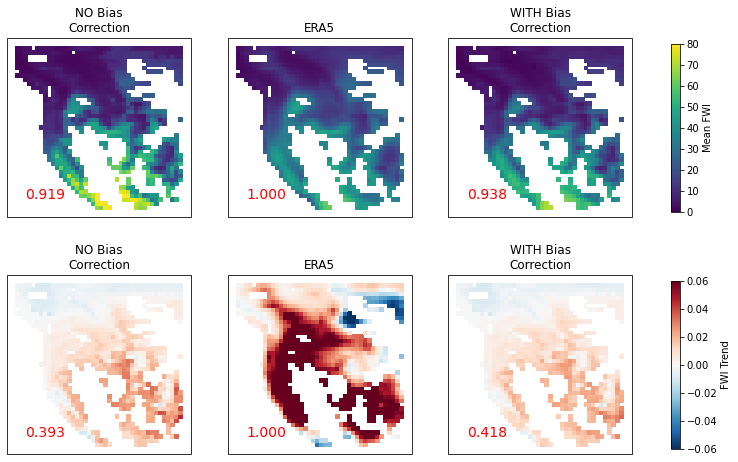

In [97]:
fig,axs = plt.subplots(2,3,figsize=(14,8),sharex=True,sharey=True,subplot_kw=dict(projection=ccrs.PlateCarree()))

titles = ['NO Bias\nCorrection', 'ERA5','WITH Bias\nCorrection']

images = {}
for i,analysis in enumerate(['mean','trend']):
    
    for j,da in enumerate([noBC_d4pdf,ERA5,BC_d4pdf]):
    
        if analysis == 'mean':
            mean = da.mean('time')
            images[analysis] = mean.plot(ax=axs[i][j],vmin=0,vmax=80,transform=ccrs.PlateCarree(),add_colorbar=False)
            
            corr = xr.corr(ERA5_mean,mean)
        
        elif analysis == 'trend':
            trend = xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True)
            images[analysis] = trend.plot(ax=axs[i][j],vmin=-0.06,vmax=0.06,cmap='RdBu_r',transform=ccrs.PlateCarree(),add_colorbar=False)

            corr = xr.corr(ERA5_trend,trend)
            
        axs[i][j].text(0.1, 0.1, f'{corr.data:.3f}', size=14, color='red', transform=axs[i][j].transAxes)

        axs[i][j].set_title(titles[j])
        
cb = fig.colorbar(images['mean'], ax=axs[0, 0:3], shrink=0.85,orientation='vertical')
cb.set_label('Mean FWI')

cb = fig.colorbar(images['trend'], ax=axs[1, 0:3], shrink=0.85,orientation='vertical')
cb.set_label('FWI Trend')

In [20]:
print('5-95 percentiles')
for config in ['noBCwind','withBCwind']:
    
    corrs = []
    
    if config == 'noBCwind':
        mean = noBC_d4pdf.mean('time')
    elif config == 'withBCwind':
        mean = BC_d4pdf.mean('time')
        
    for ens_mem in range(1,101):

        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        if config == 'noBCwind':
            ens_mem = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_HPB_m'+number+'.nc').mean('time')
            corrs.append(xr.corr(ens_mem,mean))
        elif config == 'withBCwind':
            ens_mem = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_m'+number+'.nc').mean('time')
            corrs.append(xr.corr(ens_mem,mean))
            
    if config == 'noBCwind':
        mean_corr = xr.corr(ERA5_mean,mean).data.tolist()
    elif config == 'withBCwind':
        mean_corr = xr.corr(ERA5_mean,mean).data.tolist()

    percentile_5 = np.percentile(corrs,5)
    percentile_95 = np.percentile(corrs,95)

    print(f'{config}: {percentile_5:.2f} - {percentile_95:.2f} ({mean_corr:.2f})')

5-95 percentiles
noBCwind: 1.00 - 1.00 (0.92)
withBCwind: 1.00 - 1.00 (0.94)


In [21]:
corrs

[<xarray.DataArray 'FWI' ()>
 array(0.99967678),
 <xarray.DataArray 'FWI' ()>
 array(0.99978394),
 <xarray.DataArray 'FWI' ()>
 array(0.9996688),
 <xarray.DataArray 'FWI' ()>
 array(0.99965068),
 <xarray.DataArray 'FWI' ()>
 array(0.99955519),
 <xarray.DataArray 'FWI' ()>
 array(0.99969133),
 <xarray.DataArray 'FWI' ()>
 array(0.99934068),
 <xarray.DataArray 'FWI' ()>
 array(0.99941879),
 <xarray.DataArray 'FWI' ()>
 array(0.99967357),
 <xarray.DataArray 'FWI' ()>
 array(0.99968207),
 <xarray.DataArray 'FWI' ()>
 array(0.99969746),
 <xarray.DataArray 'FWI' ()>
 array(0.99965101),
 <xarray.DataArray 'FWI' ()>
 array(0.99981647),
 <xarray.DataArray 'FWI' ()>
 array(0.99961338),
 <xarray.DataArray 'FWI' ()>
 array(0.99985174),
 <xarray.DataArray 'FWI' ()>
 array(0.99960983),
 <xarray.DataArray 'FWI' ()>
 array(0.99957281),
 <xarray.DataArray 'FWI' ()>
 array(0.99958916),
 <xarray.DataArray 'FWI' ()>
 array(0.99952908),
 <xarray.DataArray 'FWI' ()>
 array(0.99987547),
 <xarray.DataArray 'F